            hh_id province             district urban_rural  hh_size  \
0  DHHS2025-00001      EST      Outlier Coastal       Rural        4   
1  DHHS2025-00002      STH         Median Urban       Urban        6   
2  DHHS2025-00003      CTR    Variance District       Urban       10   
3  DHHS2025-00004      CTR  Numerica Peri-Urban       Urban        4   
4  DHHS2025-00005      EST    Skewness District       Urban        2   

   n_children  n_working_age  n_elderly  monthly_income  monthly_expenditure  \
0           0              4          0           82538                68093   
1           1              5          0           84311                86612   
2           1              9          0           25946                23079   
3           3              1          0           40904                34869   
4           1              1          0           32510                27706   

   has_electricity  has_improved_water  has_improved_sanitation  owns_radio  \
0      

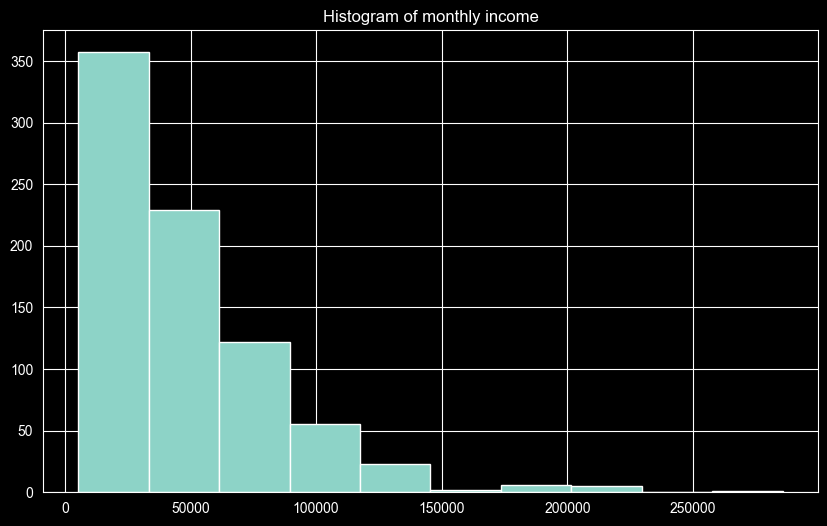

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from py4stat import datania

# Load household survey data
hh_data = datania.generate_household_survey(n_households=800, seed=42)
df = pd.read_csv(hh_data)

# Preview the data
print(df.head())
print(f"\nDataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

# Task 1: Create a matplotlib histogram of monthly_income
# YOUR CODE HERE
plt.figure(figsize=(10, 6))
df["monthly_income"].hist(bins=10)
plt.title("Histogram of monthly income")
# ... complete the histogram ...
plt.show()

# Task 2: Create the same histogram using Plotly Express
# YOUR CODE HERE
# fig = px.histogram(...)
# fig.show()
fig = px.histogram(df, x="monthly_income")
fig.show()

# Task 3: Create a Plotly box plot comparing income across provinces
# YOUR CODE HERE
# fig = px.box(...)
# fig.show()
fig = px.box(df, x="monthly_income", y="province")
fig.show()

# Task 4: Export your Plotly visualization as HTML
# Hint: Use fig.write_html("filename.html")
# YOUR CODE HERE

In [11]:
import plotly.graph_objects as go

df = pd.read_csv(datania.generate_census_data(n_persons=8000, seed=42))
print(df.head())
# Prepare data: age groups by sex
age_bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 100]
age_labels = ['0-4', '5-9', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39',
              '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80+']

df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

# Count by age group and sex
pyramid_data = df.groupby(['age_group', 'sex']).size().unstack(fill_value=0)

# Create pyramid
fig = go.Figure()

# Males (negative values for left side)
fig.add_trace(go.Bar(
    y=pyramid_data.index,
    x=-pyramid_data['Male'],
    name='Male',
    orientation='h',
    marker_color='steelblue',
    hovertemplate='Male<br>Age: %{y}<br>Count: %{customdata}<extra></extra>',
    customdata=pyramid_data['Male']
))

# Females (positive values for right side)
fig.add_trace(go.Bar(
    y=pyramid_data.index,
    x=pyramid_data['Female'],
    name='Female',
    orientation='h',
    marker_color='coral',
    hovertemplate='Female<br>Age: %{y}<br>Count: %{x}<extra></extra>'
))

fig.update_layout(
    title='Population Pyramid: Datania Household Survey',
    barmode='overlay',
    bargap=0.1,
    xaxis=dict(
        title='Population Count',
        tickvals=[-400, -300, -200, -100, 0, 100, 200, 300, 400],
        ticktext=['400', '300', '200', '100', '0', '100', '200', '300', '400']
    ),
    yaxis=dict(title='Age Group'),
    legend=dict(x=0.8, y=0.95)
)

fig.show()

         person_id      hh_id province            district urban_rural  \
0  PHC2020-0000001  HH-001000      NTH    Polaris District       Rural   
1  PHC2020-0000002  HH-001000      NTH    Polaris District       Rural   
2  PHC2020-0000003  HH-001000      CTR   Variance District       Urban   
3  PHC2020-0000004  HH-001000      LKS  Parameter District       Rural   
4  PHC2020-0000005  HH-001000      EST   Skewness District       Urban   

       ea_code  age     sex       education_level      marital_status  \
0  NTH-POL-024   23  Female  Secondary incomplete          Cohabiting   
1  NTH-POL-033    7    Male    Primary incomplete       Never married   
2  CTR-VAR-092   80  Female    Primary incomplete  Divorced/Separated   
3  LKS-PAR-051   25  Female                   NaN  Divorced/Separated   
4  EST-SKE-002   25  Female    Primary incomplete             Married   

  relationship_to_head  
0                 Head  
1         Son/Daughter  
2         Son/Daughter  
3           Gran